In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from utils import *

# 1 Load Data

In [2]:
# load trajecty for cpi

cpi_traj = np.load("data/cpi_trajectory.npz")['trajectory']
cpi_traj.shape


(788,)

In [3]:
# remove first 50 values to get targets only
targets = cpi_traj[50:]
targets.shape

(738,)

In [4]:
cpi_preds_chronos = np.load("data/predictions/chronos/chronos2_cpi.npz")['yhat_q']
cpi_preds_chronos.shape

(738, 1, 1)

In [5]:
cpi_preds_timesfm = np.load("data/predictions/timesfm/timesfm_cpi.npz")['yhat']
cpi_preds_timesfm.shape

(738, 1)

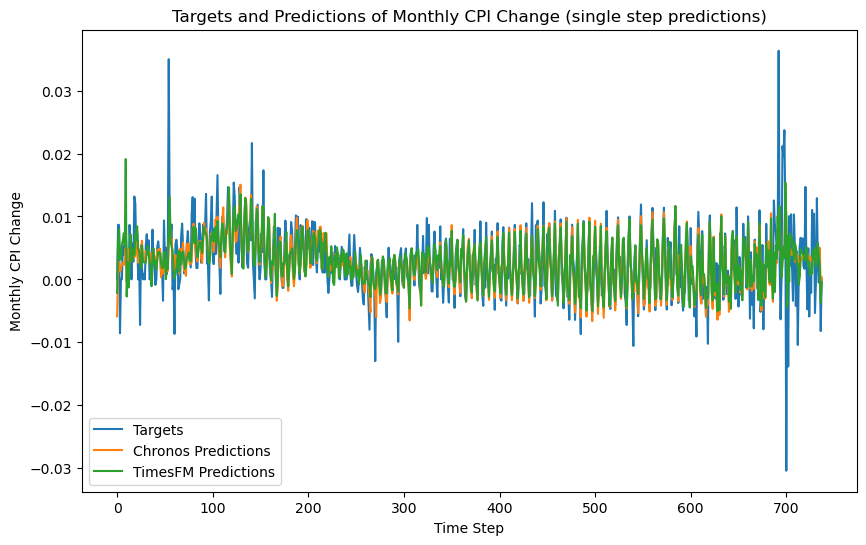

In [6]:
# plot line plot of targets and predictions
plt.figure(figsize=(10, 6))
plt.plot(targets, label='Targets')
plt.plot(cpi_preds_chronos[:, 0, 0], label='Chronos Predictions')
plt.plot(cpi_preds_timesfm[:, 0], label='TimesFM Predictions')
plt.xlabel('Time Step')
plt.ylabel('Monthly CPI Change')
plt.title('Targets and Predictions of Monthly CPI Change (single step predictions)')
plt.legend()
plt.show()

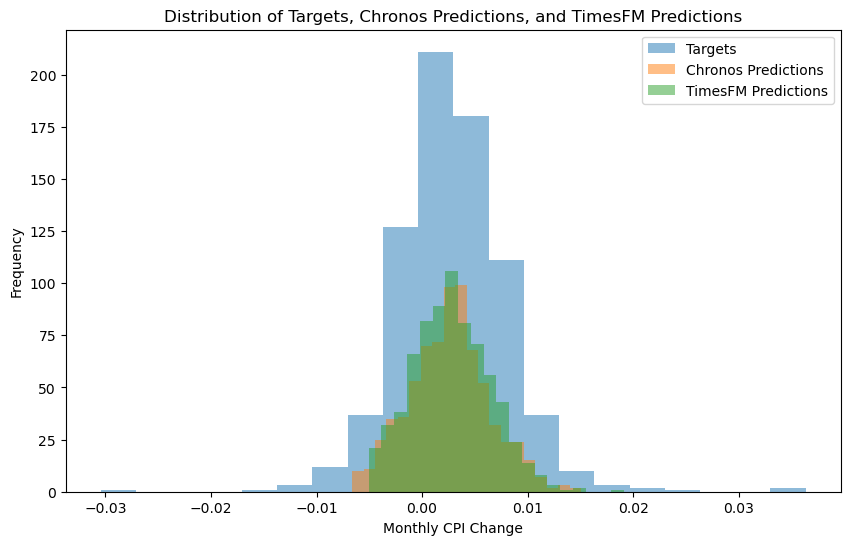

In [7]:
# plot histogram of preds and targets

plt.figure(figsize=(10, 6))
plt.hist(targets, bins=20, alpha=0.5, label='Targets')
plt.hist(cpi_preds_chronos[:, 0, 0], bins=20, alpha=0.5, label='Chronos Predictions')
plt.hist(cpi_preds_timesfm[:, 0], bins=20, alpha=0.5, label='TimesFM Predictions')
plt.xlabel('Monthly CPI Change')
plt.ylabel('Frequency')
plt.title('Distribution of Targets, Chronos Predictions, and TimesFM Predictions')
plt.legend()
plt.show()

C:\Users\JanderM\AppData\Local\Temp\ipykernel_3648\1120170996.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([targets, cpi_preds_chronos[:, 0, 0], cpi_preds_timesfm[:, 0]], labels=['Targets', 'Chronos Predictions', 'TimesFM Predictions'])


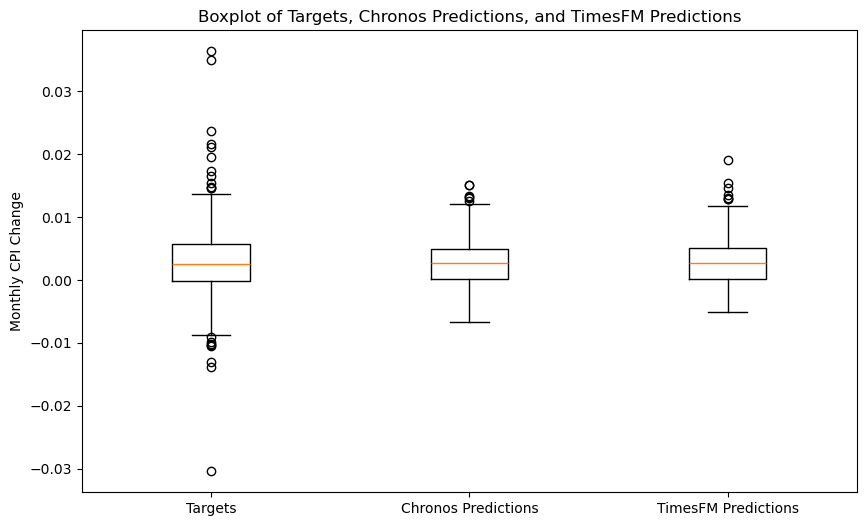

In [8]:
# show boxplot of preds and targets
plt.figure(figsize=(10, 6))
plt.boxplot([targets, cpi_preds_chronos[:, 0, 0], cpi_preds_timesfm[:, 0]], labels=['Targets', 'Chronos Predictions', 'TimesFM Predictions'])
plt.ylabel('Monthly CPI Change')
plt.title('Boxplot of Targets, Chronos Predictions, and TimesFM Predictions')
plt.show()


In [9]:
# print mean and median of preds and targets
print(f"Mean of targets: {np.mean(targets)}")
print(f"Median of targets: {np.median(targets)}")
print(f"Mean of Chronos predictions: {np.mean(cpi_preds_chronos[:, 0, 0])}")
print(f"Median of Chronos predictions: {np.median(cpi_preds_chronos[:, 0, 0])}")
print(f"Mean of TimesFM predictions: {np.mean(cpi_preds_timesfm[:, 0])}")
print(f"Median of TimesFM predictions: {np.median(cpi_preds_timesfm[:, 0])}")


Mean of targets: 0.0027908319851822107
Median of targets: 0.002509537385337879
Mean of Chronos predictions: 0.0026132373604923487
Median of Chronos predictions: 0.0026719453744590282
Mean of TimesFM predictions: 0.0028162188827991486
Median of TimesFM predictions: 0.002676231786608696


# 2 Evaluation

In [10]:
# calculate probability of upward movement in targets and predictions
prob_up_targets = np.mean(targets > 0)
prob_up_chronos = np.mean(cpi_preds_chronos[:, 0, 0] > 0)
prob_up_timesfm = np.mean(cpi_preds_timesfm[:, 0] > 0)
print(f"Probability of upward movement in targets: {prob_up_targets}")
print(f"Probability of upward movement in Chronos predictions: {prob_up_chronos}")
print(f"Probability of upward movement in TimesFM predictions: {prob_up_timesfm}")


Probability of upward movement in targets: 0.6883468834688347
Probability of upward movement in Chronos predictions: 0.7588075880758808
Probability of upward movement in TimesFM predictions: 0.7642276422764228


In [11]:
# calculate wasserstein distance between targets and predictions
f = np.arange(len(targets))
wasserstein_chronos = wasserstein_1d_on_grid(f, targets, cpi_preds_chronos[:, 0, 0])
wasserstein_timesfm = wasserstein_1d_on_grid(f, targets, cpi_preds_timesfm[:, 0])
print(f"Wasserstein distance between targets and Chronos predictions: {wasserstein_chronos}")
print(f"Wasserstein distance between targets and TimesFM predictions: {wasserstein_timesfm}")


Wasserstein distance between targets and Chronos predictions: 11.699824391140936
Wasserstein distance between targets and TimesFM predictions: 16.628377140947617


In [12]:
# calculate MAE between targets and predictions
mae_chronos = np.mean(np.abs(targets - cpi_preds_chronos[:, 0, 0]))
mae_timesfm = np.mean(np.abs(targets - cpi_preds_timesfm[:, 0]))
print(f"MAE between targets and Chronos predictions: {mae_chronos}")
print(f"MAE between targets and TimesFM predictions: {mae_timesfm}")


MAE between targets and Chronos predictions: 0.002592841342566598
MAE between targets and TimesFM predictions: 0.0026897721205284835


In [13]:
# calcualte MSE between targets and predictions
mse_chronos = np.mean((targets - cpi_preds_chronos[:, 0, 0]) ** 2)
mse_timesfm = np.mean((targets - cpi_preds_timesfm[:, 0]) ** 2)
print(f"MSE between targets and Chronos predictions: {mse_chronos}")
print(f"MSE between targets and TimesFM predictions: {mse_timesfm}")

# Calculate RMSE between targets and predictions
rmse_chronos = np.sqrt(mse_chronos)
rmse_timesfm = np.sqrt(mse_timesfm)
print(f"RMSE between targets and Chronos predictions: {rmse_chronos}")
print(f"RMSE between targets and TimesFM predictions: {rmse_timesfm}")


MSE between targets and Chronos predictions: 1.656102840826557e-05
MSE between targets and TimesFM predictions: 1.7425208062117394e-05
RMSE between targets and Chronos predictions: 0.004069524346685441
RMSE between targets and TimesFM predictions: 0.004174351214514346


It seems that Chronos and TimesFM have similar performance on CPI dataset which is assumed to have positive drift. This is in line with the results of Experiment 1 in which both models showed sensitivity to drift.